In [4]:
import os
from google.colab import drive

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_703db1c40fe18c57c118e623ed0c60a8'

drive.mount('/content/drive')

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d /content/dataset/

print("Đã tải và giải nén dữ liệu hoàn tất!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:28<00:00, 87.2MB/s]

replace /content/dataset/chest_xray/__MACOSX/._chest_xray? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/dataset/chest_xray/__MACOSX/chest_xray/._.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: Đã tải và giải nén dữ liệu hoàn tất!


Đang gộp 16 ảnh từ thư mục 'val' cũ vào 'train' để tự động chia lại...

--- Đang tải dữ liệu lên RAM ---
Found 4448 images belonging to 2 classes.
Found 784 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Trọng số lớp đã tính toán: {0: 1.93897122929381, 1: 0.6737352317479551}

--- Bắt đầu huấn luyện CNN... ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.7782 - loss: 2.1780
Epoch 1: val_accuracy improved from None to 0.74235, saving model to /content/drive/MyDrive/chest_xray_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/chest_xray_best_model.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 61s 358ms/step - accuracy: 0.8094 - loss: 1.0661 - val_accuracy: 0.7423 - val_loss: 14.7407 - learning_rate: 0.0010
Epoch 2/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.8499 - loss: 0.4366
Epoch 2: val_accuracy did not improve from 0.74235
139/139 ━━━━━━━━━━━━━━━━━━━━ 44s 316ms/step - accuracy: 0.8282 - loss: 0.4043 - val_accuracy: 0.7423 - val_loss: 27.7287 - learning_rate: 0.0010
Epoch 3/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.8669 - loss: 0.2994
Epoch 3: val_accuracy did not improve from 0.74235
139/139 ━━━━━━━━━━━━━━━━━━━━ 42s 304ms/step - accuracy: 0.8622 - loss: 0.3343 - val_accuracy: 0.7423 - val_loss: 12.6535 - learning_rate: 

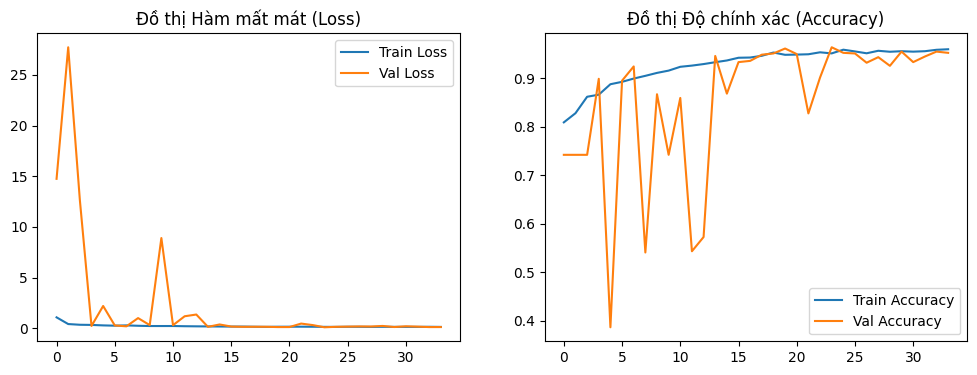

In [6]:
import os
import shutil
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. DỌN DẸP VÀ GỘP DỮ LIỆU ĐỂ GIẢI QUYẾT TẬP VAL QUÁ NHỎ ---
base_dir = '/content/dataset/chest_xray'
train_dir = os.path.join(base_dir, 'train')
val_dir_old = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

print("Đang gộp 16 ảnh từ thư mục 'val' cũ vào 'train' để tự động chia lại...")
for category in ['NORMAL', 'PNEUMONIA']:
    old_val_path = os.path.join(val_dir_old, category)
    train_cat_path = os.path.join(train_dir, category)
    if os.path.exists(old_val_path):
        for img_file in os.listdir(old_val_path):
            src = os.path.join(old_val_path, img_file)
            dst = os.path.join(train_cat_path, img_file)
            if not os.path.exists(dst): # Tránh copy đè nếu chạy nhiều lần
                shutil.copy(src, dst)

# --- 2. TIỀN XỬ LÝ & DATA AUGMENTATION ---
IMG_SIZE = 150
BATCH_SIZE = 32

# Áp dụng Augmentation cho tập Train và trích ra 15% làm tập Validation mới
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,       # Xoay nhẹ ảnh
    width_shift_range=0.1,   # Dịch ngang
    height_shift_range=0.1,  # Dịch dọc
    zoom_range=0.1,          # Phóng to/thu nhỏ
    horizontal_flip=True,    # Lật ngang
    validation_split=0.15    # Dùng 15% dữ liệu Train để làm Validation
)

# Tập Test CHỈ ĐƯỢC chuẩn hóa pixel, KHÔNG biến dạng ảnh
test_datagen = ImageDataGenerator(rescale=1./255)

print("\n--- Đang tải dữ liệu lên RAM ---")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale', # Ảnh X-Quang dùng ảnh xám
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale',
    shuffle=False # Bắt buộc False để tí nữa đánh giá Classification Report
)

# --- 3. TÍNH TOÁN TRỌNG SỐ LỚP (CLASS WEIGHTS) ---
# Đếm số lượng ảnh Normal (0) và Pneumonia (1) để phạt mô hình nếu nó thiên vị
num_normal = train_generator.classes.tolist().count(0)
num_pneumonia = train_generator.classes.tolist().count(1)
total = num_normal + num_pneumonia

weight_for_0 = (1 / num_normal) * (total / 2.0)
weight_for_1 = (1 / num_pneumonia) * (total / 2.0)
class_weights = {0: weight_for_0, 1: weight_for_1}
print(f"\nTrọng số lớp đã tính toán: {class_weights}")

# --- 4. XÂY DỰNG KIẾN TRÚC CUSTOM CNN TỐI ƯU ---
model = Sequential([
    # Khối 1
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    BatchNormalization(), # Tăng tốc độ hội tụ, giảm răng cưa
    MaxPool2D(2, 2),

    # Khối 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(2, 2),

    # Khối 3
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(2, 2),

    # Phân loại
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Chống học vẹt (Overfitting)
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- 5. CẤU HÌNH CÁC CALLBACKS THÔNG MINH ---
checkpoint_path = '/content/drive/MyDrive/chest_xray_best_model.keras'

callbacks = [
    # Lưu model có val_accuracy cao nhất
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1),
    # Giảm Learning Rate đi 1 nửa nếu sau 3 epochs val_loss không giảm
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6),
    # Dừng sớm nếu sau 10 epochs mô hình không tiến bộ nữa
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

# --- 6. HUẤN LUYỆN MÔ HÌNH ---
print("\n--- Bắt đầu huấn luyện CNN... ---")
epochs = 50
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    class_weight=class_weights, # Áp dụng trọng số phạt
    callbacks=callbacks
)

# --- 7. ĐÁNH GIÁ TRÊN TẬP TEST ---
print("\n--- Đánh giá kết quả trên tập Test ---")
# Load lại trọng số tốt nhất vừa lưu
model.load_weights(checkpoint_path)

test_loss, test_acc = model.evaluate(test_generator)
print(f"Độ chính xác trên tập Test (Test Accuracy): {test_acc*100:.2f}%")

# Báo cáo chi tiết Precision, Recall, F1-Score
test_generator.reset()
preds = model.predict(test_generator)
preds_classes = np.where(preds > 0.5, 1, 0) # Ngưỡng 0.5
true_classes = test_generator.classes

print("\nBÁO CÁO PHÂN LOẠI:")
print(classification_report(true_classes, preds_classes, target_names=['NORMAL', 'PNEUMONIA']))

# --- 8. VẼ BIỂU ĐỒ ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Đồ thị Hàm mất mát (Loss)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Đồ thị Độ chính xác (Accuracy)')
plt.legend()
plt.show()

In [7]:
!pip install transformers torch torchvision scikit-learn

[*] Đang chạy trên thiết bị: cuda

--- Đang kiểm tra và dọn dẹp các file ảnh bị lỗi... ---
Đã dọn dẹp xong! Số lượng file lỗi bị xóa: 0

--- Đang gộp và chia lại tập Train / Validation... ---
Số ảnh Train mới: 4460 | Val mới: 788
Trọng số lớp đã tính: Normal=1.93, Pneumonia=0.67

--- Đang tải mô hình Vision Transformer (HuggingFace)... ---


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.



--- Bắt đầu huấn luyện ViT... ---
Epoch 1/10 [251.1s] - Train Loss: 0.1514 - Val Acc: 94.92%
  -> Đã lưu model tốt nhất (Acc: 94.92%)
Epoch 2/10 [250.3s] - Train Loss: 0.0695 - Val Acc: 97.72%
  -> Đã lưu model tốt nhất (Acc: 97.72%)
Epoch 3/10 [249.9s] - Train Loss: 0.0622 - Val Acc: 96.95%
Epoch 4/10 [249.5s] - Train Loss: 0.0393 - Val Acc: 94.67%
Epoch 5/10 [250.4s] - Train Loss: 0.0365 - Val Acc: 97.34%
Epoch 6/10 [253.0s] - Train Loss: 0.0223 - Val Acc: 97.46%
Epoch 7/10 [251.7s] - Train Loss: 0.0192 - Val Acc: 98.48%
  -> Đã lưu model tốt nhất (Acc: 98.48%)
Epoch 8/10 [252.9s] - Train Loss: 0.0115 - Val Acc: 97.72%
Epoch 9/10 [253.1s] - Train Loss: 0.0119 - Val Acc: 98.60%
  -> Đã lưu model tốt nhất (Acc: 98.60%)
Epoch 10/10 [253.6s] - Train Loss: 0.0122 - Val Acc: 97.84%

--- Đánh giá mô hình trên tập Test ---

BÁO CÁO PHÂN LOẠI:
              precision    recall  f1-score   support

      NORMAL       0.99      0.54      0.70       234
   PNEUMONIA       0.78      1.00      0.

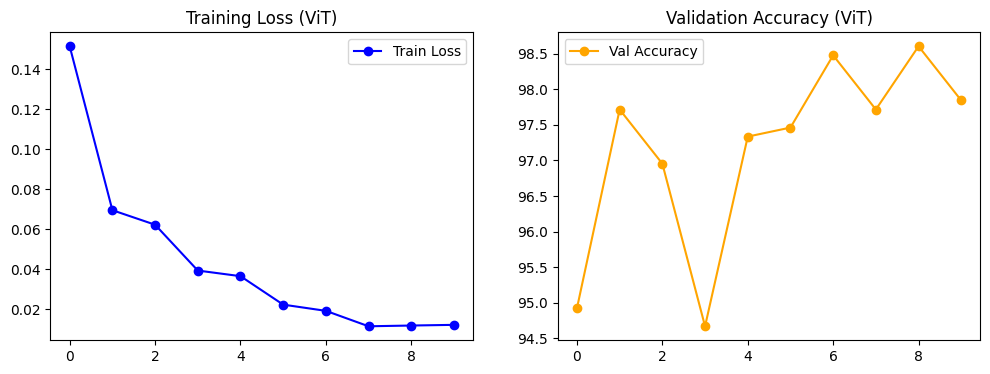

In [11]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, ConcatDataset
from transformers import ViTForImageClassification
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import numpy as np
from PIL import Image

# ==============================================================================
# BƯỚC 1: CẤU HÌNH KAGGLE VÀ TẢI DỮ LIỆU
# ==============================================================================
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_703db1c40fe18c57c118e623ed0c60a8'
if not os.path.exists('/content/dataset/chest_xray'):
    print("Đang tải dữ liệu từ Kaggle...")
    !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
    print("Đang giải nén dữ liệu...")
    !unzip -o -q chest-xray-pneumonia.zip -d /content/dataset/
    print("Đã tải và giải nén xong!")

# ==============================================================================
# BƯỚC 2: CẤU HÌNH ĐƯỜNG DẪN VÀ DỌN DẸP ẢNH LỖI
# ==============================================================================
DATA_DIR = '/content/dataset/chest_xray'
MODEL_PATH = '/content/vit_chest_xray_pytorch_best.pth'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Đang chạy trên thiết bị: {device}")

print("\n--- Đang kiểm tra và dọn dẹp các file ảnh bị lỗi... ---")
folders_to_check = [os.path.join(DATA_DIR, 'train'), os.path.join(DATA_DIR, 'val'), os.path.join(DATA_DIR, 'test')]
removed_count = 0
for folder in folders_to_check:
    if os.path.exists(folder):
        for root, dirs, files in os.walk(folder):
            for file in files:
                file_path = os.path.join(root, file)
                try:
                    img = Image.open(file_path)
                    img.verify()
                except Exception:
                    os.remove(file_path)
                    removed_count += 1
print(f"Đã dọn dẹp xong! Số lượng file lỗi bị xóa: {removed_count}")

# ==============================================================================
# BƯỚC 3: ĐỊNH NGHĨA TIỀN XỬ LÝ (TRANSFORMS) - 224x224 CHO ViT
# ==============================================================================
IMAGE_SIZE = 224
BATCH_SIZE = 32

transform_train = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val_test = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==============================================================================
# BƯỚC 4: GỘP TRAIN + VAL CŨ VÀ CHIA LẠI TỶ LỆ
# ==============================================================================
print("\n--- Đang gộp và chia lại tập Train / Validation... ---")
full_train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'))
val_dataset_old = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'))

# Gộp dữ liệu thô (chưa transform)
combined_dataset = ConcatDataset([full_train_dataset, val_dataset_old])
all_labels = [label for _, label in combined_dataset]

# Chia 85% Train - 15% Validation
train_idx, val_idx = train_test_split(list(range(len(all_labels))), test_size=0.15, random_state=42, stratify=all_labels)

# Custom class để áp dụng transform khác nhau
class CustomSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform
    def __getitem__(self, idx):
        image, label = self.dataset[self.indices[idx]]
        if self.transform: image = self.transform(image)
        return image, label
    def __len__(self): return len(self.indices)

train_dataset = CustomSubset(combined_dataset, train_idx, transform=transform_train)
val_dataset = CustomSubset(combined_dataset, val_idx, transform=transform_val_test)
test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), transform=transform_val_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Số ảnh Train mới: {len(train_dataset)} | Val mới: {len(val_dataset)}")

# ==============================================================================
# BƯỚC 5: TÍNH TOÁN TRỌNG SỐ LỚP (CLASS WEIGHTS)
# ==============================================================================
train_labels = [all_labels[i] for i in train_idx]
class_counts = np.bincount(train_labels)
weights = sum(class_counts) / (len(class_counts) * class_counts)
class_weights = torch.FloatTensor(weights).to(device)
print(f"Trọng số lớp đã tính: Normal={weights[0]:.2f}, Pneumonia={weights[1]:.2f}")

# ==============================================================================
# BƯỚC 6: KHỞI TẠO MÔ HÌNH VISION TRANSFORMER (ViT)
# ==============================================================================
print("\n--- Đang tải mô hình Vision Transformer (HuggingFace)... ---")
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=2,
    ignore_mismatched_sizes=True
).to(device)

# ==============================================================================
# BƯỚC 7: CẤU HÌNH HUẤN LUYỆN
# ==============================================================================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-4)

# ĐÃ SỬA LỖI Ở ĐÂY: Xóa bỏ tham số verbose=True
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

num_epochs = 10
best_acc = 0.0
history = {'train_loss': [], 'val_acc': []}

# ==============================================================================
# BƯỚC 8: VÒNG LẶP HUẤN LUYỆN
# ==============================================================================
print("\n--- Bắt đầu huấn luyện ViT... ---")
for epoch in range(num_epochs):
    start_time = time.time()

    # Huấn luyện (Train)
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # Đánh giá (Validation)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs).logits
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    history['train_loss'].append(avg_train_loss)
    history['val_acc'].append(val_acc)

    # Cập nhật Scheduler
    scheduler.step(val_acc)

    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{num_epochs} [{epoch_time:.1f}s] - Train Loss: {avg_train_loss:.4f} - Val Acc: {val_acc:.2f}%")

    # Lưu mô hình tốt nhất
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), MODEL_PATH)
        print(f"  -> Đã lưu model tốt nhất (Acc: {val_acc:.2f}%)")

# ==============================================================================
# BƯỚC 9: ĐÁNH GIÁ TRÊN TẬP TEST VÀ VẼ BIỂU ĐỒ
# ==============================================================================
print("\n--- Đánh giá mô hình trên tập Test ---")
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

all_preds, all_labels_test = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs).logits
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels_test.extend(labels.cpu().numpy())

print("\nBÁO CÁO PHÂN LOẠI:")
print(classification_report(all_labels_test, all_preds, target_names=["NORMAL", "PNEUMONIA"]))

# Vẽ đồ thị
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue', marker='o')
plt.title('Training Loss (ViT)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], label='Val Accuracy', color='orange', marker='o')
plt.title('Validation Accuracy (ViT)')
plt.legend()
plt.show()

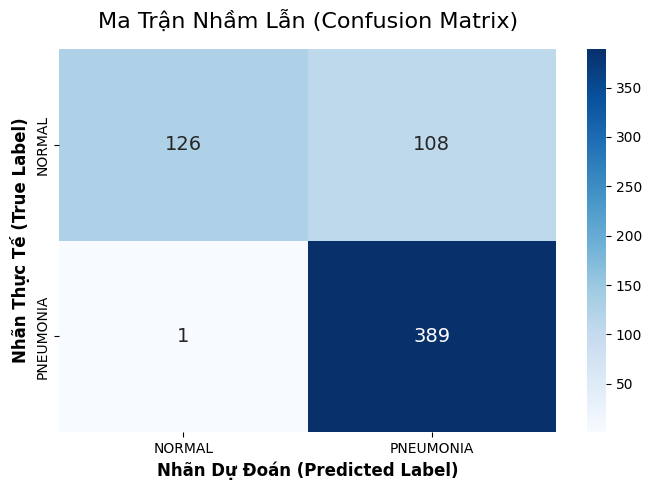

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, target_names):
    """
    Hàm tính toán và vẽ biểu đồ Ma trận nhầm lẫn (Confusion Matrix)
    """
    # 1. Tính toán ma trận
    cm = confusion_matrix(y_true, y_pred)

    # 2. Khởi tạo khung vẽ
    plt.figure(figsize=(7, 5))

    # 3. Vẽ heatmap bằng Seaborn
    # annot=True: Hiện con số trên từng ô
    # fmt='d': Định dạng số nguyên
    # cmap='Blues': Chọn tông màu xanh dương y tế
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names,
                annot_kws={"size": 14}) # Phóng to font chữ số

    # 4. Tùy chỉnh tiêu đề và nhãn
    plt.title('Ma Trận Nhầm Lẫn (Confusion Matrix)', fontsize=16, pad=15)
    plt.ylabel('Nhãn Thực Tế (True Label)', fontsize=12, fontweight='bold')
    plt.xlabel('Nhãn Dự Đoán (Predicted Label)', fontsize=12, fontweight='bold')

    # 5. Căn chỉnh và hiển thị
    plt.tight_layout()
    plt.show()

# ==========================================
# CÁCH GỌI HÀM (Áp dụng cho dự án X-Quang của bạn)
# ==========================================
# Đảm bảo bạn đã chạy xong phần Test ở code trên để có 2 biến này
classes = ["NORMAL", "PNEUMONIA"]
plot_confusion_matrix(all_labels_test, all_preds, classes)